In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
from heston.closed import heston_closed_price
from heston.tree import HestonTreeFast

from neural_network.payoff import Call, Put
from neural_network.config import ModelConfig, HestonParams
from neural_network.trainer import HestonTrainer

In [2]:
exercise_type = 'american'
option_type = 'put'
payoff = Put() if option_type == 'put' else Call()

In [3]:
S0 = 1.0   # Initial stock price
K = 1.0    # Strike price
T = 1.0      # Time to maturity
r = 0.05     # Risk-free rate
kappa = 2.0  # Mean reversion rate
theta = 0.04 # Long-term variance
sigma = 0.3  # Volatility of variance
rho = -0.7   # Correlation
v0 = 0.04    # Initial variance

## Neural network vs Tree

In [ ]:
S_max = 3 * S0
V_max = 0.8

params = HestonParams(
    S0=S0, v0=v0, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho, T=T, K=K,
    S_max=S_max, V_max=V_max
)

model_config = ModelConfig(
    input_size=3,
    hidden_sizes=[64, 128, 128, 64],
    output_size=1,
    activation=nn.ReLU(),
    learning_rate=1e-4
)

loss_weights = {
    'pde': 5000.0,
    'payoff': 0.5,
    'S_min': 10.0,
    'S_max': 10.0,
    'V_min': 1000.0,
    'V_max': 0.01
}

heston_trainer = HestonTrainer(model_config=model_config, heston_params=params, payoff=payoff, exercise_type=exercise_type, loss_weights=loss_weights, seed=42)

Iteration 0, Loss: 329.76959228515625
Iteration 100, Loss: 85.34027099609375
Iteration 200, Loss: 10.862388610839844
Iteration 300, Loss: 2.284402370452881
Iteration 400, Loss: 1.019937515258789
Iteration 500, Loss: 0.4374350309371948
Iteration 600, Loss: 0.1462777554988861
Iteration 700, Loss: 0.5102065205574036
Iteration 800, Loss: 0.44147369265556335
Iteration 900, Loss: 0.2618734836578369
Iteration 1000, Loss: 0.45837393403053284
Iteration 1100, Loss: 0.8113797307014465
Iteration 1200, Loss: 0.28433459997177124
Iteration 1300, Loss: 4.395914077758789
Iteration 1400, Loss: 1.581053614616394
Iteration 1500, Loss: 3.793591260910034
Iteration 1600, Loss: 1.7377856969833374
Iteration 1700, Loss: 2.7205467224121094
Iteration 1800, Loss: 1.661850929260254
Iteration 1900, Loss: 0.9743549823760986
Iteration 2000, Loss: 1.582714319229126
Iteration 2100, Loss: 1.2748628854751587
Iteration 2200, Loss: 0.7698915600776672
Iteration 2300, Loss: 0.7591824531555176
Iteration 2400, Loss: 1.065400481

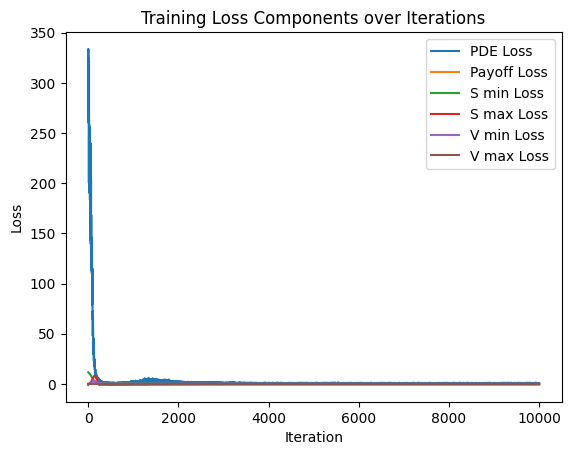

In [5]:
heston_trainer.train(batch_size=1024, epochs=10000, tol=1e-5)
heston_trainer.plot_losses_detailed()

In [12]:
# Heston Tree
n = 100
mv = 3 * n
mz = 6 * n
tree = HestonTreeFast(n=100, mz=mz, mv=mv, K=K, T=T, r=r, kappa=kappa, theta=theta, sigma=sigma, rho=rho)
tree.build_tree(0.01, V_max, 0.01, S_max, option_type=option_type, exercise_type=exercise_type)

In [16]:
# grid resolution
num_S = 80
num_V = 80

Ss = np.linspace(0.01, S_max, num_S)
Vs = np.linspace(0.01, V_max, num_V)
t = 0

nn_prices = np.zeros((num_V, num_S))
ht_prices = np.zeros((num_V, num_S))

for i, v_val in enumerate(Vs):
    for j, s_val in enumerate(Ss):
        nn_prices[i, j] = heston_trainer.predict(t, s_val, v_val).item()
        ht_prices[i, j] = tree.price(v_val, s_val, t)

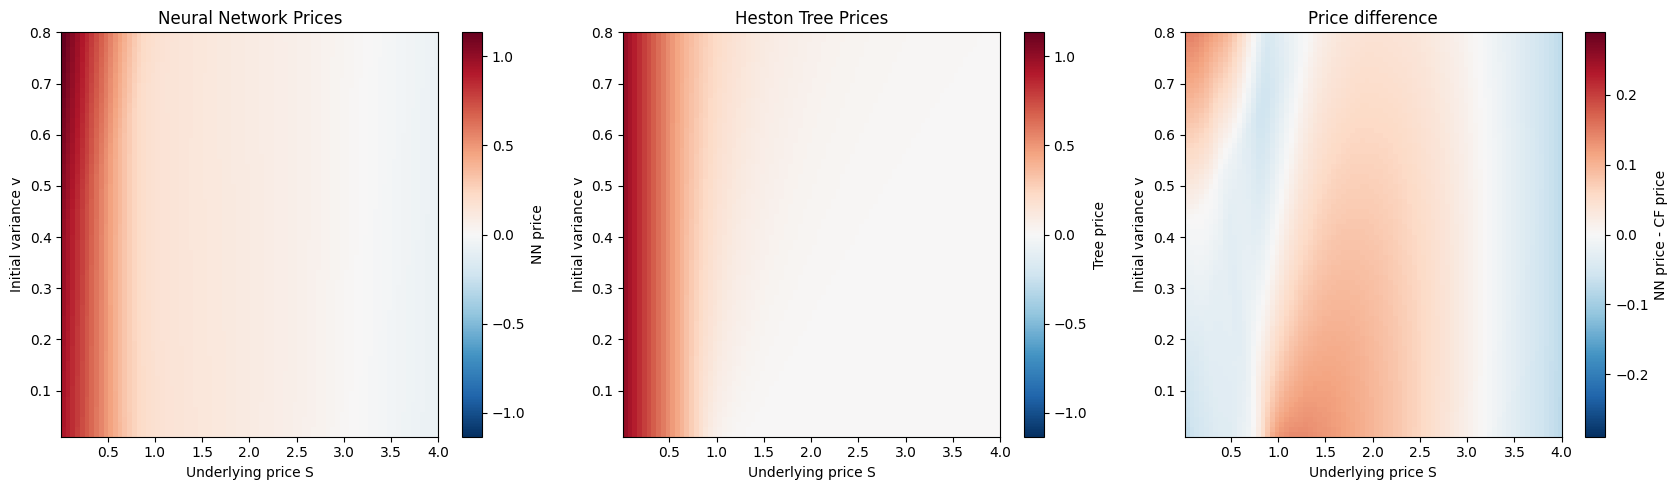

In [17]:
plt.figure(figsize=(17, 5))

plt.subplot(1, 3, 1)
vmax = np.abs(nn_prices).max()
vmin = -vmax
im = plt.imshow(nn_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im, label='NN price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Neural Network Prices')

plt.subplot(1, 3, 2)
im2 = plt.imshow(ht_prices, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im2, label='Tree price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Heston Tree Prices')

plt.subplot(1, 3, 3)
diff = nn_prices - ht_prices
vmax = np.abs(diff).max()*2
vmin = -vmax
im3 = plt.imshow(diff, extent=[Ss[0], Ss[-1], Vs[0], Vs[-1]],
                aspect='auto', origin='lower', cmap='RdBu_r', vmin=vmin, vmax=vmax)
plt.colorbar(im3, label='NN price - CF price')
plt.xlabel('Underlying price S')
plt.ylabel('Initial variance v')
plt.title('Price difference')
plt.tight_layout()
plt.show()

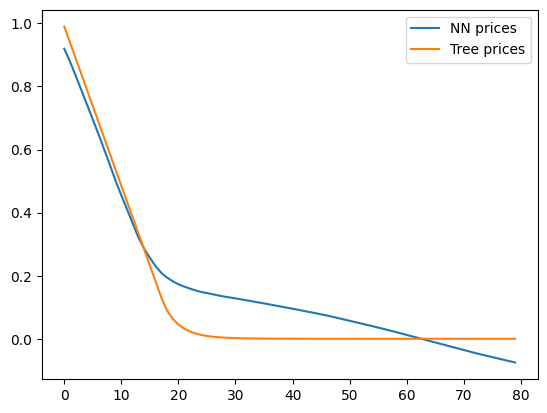

In [18]:
v_ind = 0
plt.plot(nn_prices[v_ind, :], label='NN prices')
plt.plot(ht_prices[v_ind, :], label='Tree prices')
plt.legend()
plt.show()